In [54]:
!pip install shap -q

In [55]:
import os
import glob
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from torchvision.models import (
    mobilenet_v3_small,
    efficientnet_b0
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [56]:
SEED = 99

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)

Seed: 99


In [57]:
class Config:

    BASE_PATH = "/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"

    INPUT_SIZE = 224

    BATCH_SIZE = 16

    EPOCHS = 10

    LR = 1e-4

    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

cfg = Config()

print(cfg.DEVICE)

cuda


In [59]:
all_images, labels = load_dataset()

print(len(all_images))

7909


In [60]:
class BreastDataset(Dataset):

    def __init__(self, paths, labels, transform=None):

        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.paths)

    def __getitem__(self, idx):

        img = Image.open(
            self.paths[idx]
        ).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [61]:
from sklearn.model_selection import train_test_split

# Step 1: 70% Train, 30% Temporary

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_images,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

# Step 2: 30% ko 15% Validation + 15% Test me divide karo

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("Train      :", len(train_paths))
print("Validation :", len(val_paths))
print("Test       :", len(test_paths))

Train      : 5536
Validation : 1186
Test       : 1187


In [62]:
simple_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

temp_dataset = BreastDataset(
    train_paths,
    train_labels,
    transform=simple_transform
)
              
temp_loader = DataLoader(
    temp_dataset,
    batch_size=32,
    shuffle=False
)

mean = 0.
std = 0.
total = 0

for imgs, _ in temp_loader:

    batch = imgs.size(0)

    imgs = imgs.view(batch, imgs.size(1), -1)

    mean += imgs.mean(2).sum(0)

    std += imgs.std(2).sum(0)

    total += batch

mean /= total
std /= total

print(mean)
print(std)

tensor([0.7867, 0.6274, 0.7641])
tensor([0.0974, 0.1306, 0.0813])


In [63]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

In [64]:
train_dataset = BreastDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = BreastDataset(
    val_paths,
    val_labels,
    transform=val_transform
)

test_dataset = BreastDataset(
    test_paths,
    test_labels,
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False
)

In [65]:
class HybridModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.model1 = mobilenet_v3_small(
            weights='DEFAULT'
        )

        self.model1.classifier = nn.Identity()

        self.model2 = efficientnet_b0(
            weights='DEFAULT'
        )

        self.model2.classifier = nn.Identity()

        self.fc = nn.Sequential(

            nn.Linear(
                576 + 1280,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                2
            )
        )

    def forward(self, x):

        feat1 = self.model1(x)

        feat2 = self.model2(x)

        fused = torch.cat(
            [feat1, feat2],
            dim=1
        )

        return self.fc(fused)

In [67]:
model = HybridModel().to(cfg.DEVICE)

best_acc, train_acc_list, val_acc_list, train_loss_list, val_loss_list = train_model(
    model,
    train_loader,
    val_loader,
    cfg.DEVICE,
    epochs=45
)

✅ Best Model Saved (Epoch 1) | Val Acc = 96.29%
Epoch [1/45] | Train Loss: 0.2725 Acc: 88.80% | Val Loss: 0.0920 Acc: 96.29%
✅ Best Model Saved (Epoch 2) | Val Acc = 97.05%
Epoch [2/45] | Train Loss: 0.1400 Acc: 94.54% | Val Loss: 0.0756 Acc: 97.05%
✅ Best Model Saved (Epoch 3) | Val Acc = 98.15%
Epoch [3/45] | Train Loss: 0.0906 Acc: 96.55% | Val Loss: 0.0543 Acc: 98.15%
Epoch [4/45] | Train Loss: 0.0586 Acc: 97.92% | Val Loss: 0.0722 Acc: 97.05%
✅ Best Model Saved (Epoch 5) | Val Acc = 98.23%
Epoch [5/45] | Train Loss: 0.0570 Acc: 97.80% | Val Loss: 0.0504 Acc: 98.23%
Epoch [6/45] | Train Loss: 0.0467 Acc: 98.43% | Val Loss: 0.0695 Acc: 97.30%
✅ Best Model Saved (Epoch 7) | Val Acc = 98.48%
Epoch [7/45] | Train Loss: 0.0397 Acc: 98.59% | Val Loss: 0.0444 Acc: 98.48%
Epoch [8/45] | Train Loss: 0.0350 Acc: 98.70% | Val Loss: 0.0459 Acc: 98.15%
Epoch [9/45] | Train Loss: 0.0384 Acc: 98.75% | Val Loss: 0.0455 Acc: 98.48%
✅ Best Model Saved (Epoch 10) | Val Acc = 98.74%
Epoch [10/45] | Tr

In [68]:
# =========================================================
# LOAD BEST MODEL
# =========================================================

model.load_state_dict(
    torch.load(
        "best_model.pth"
    )
)

model.eval()

print("✅ Best model loaded successfully.")

✅ Best model loaded successfully.


In [69]:
# =========================================================
# EVALUATION ON TEST SET
# =========================================================

from sklearn.metrics import roc_curve, auc

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(cfg.DEVICE)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        _, predicted = torch.max(
            outputs,
            1
        )

        all_preds.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

# Save for ROC
y_true = all_labels
y_prob = all_probs
# =========================================================
# METRICS
# =========================================================

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds
)

recall = recall_score(
    all_labels,
    all_preds
)

f1 = f1_score(
    all_labels,
    all_preds
)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)

print(
    f"Accuracy  : {accuracy*100:.2f}%"
)

print(
    f"Precision : {precision*100:.2f}%"
)

print(
    f"Recall    : {recall*100:.2f}%"
)

print(
    f"F1 Score  : {f1*100:.2f}%"
)


TEST SET RESULTS
Accuracy  : 98.57%
Precision : 99.14%
Recall    : 98.77%
F1 Score  : 98.96%


In [70]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print("AUC =", roc_auc)

AUC = 0.9991523187545353


In [71]:
DEVICE = cfg.DEVICE
print(DEVICE)

cuda


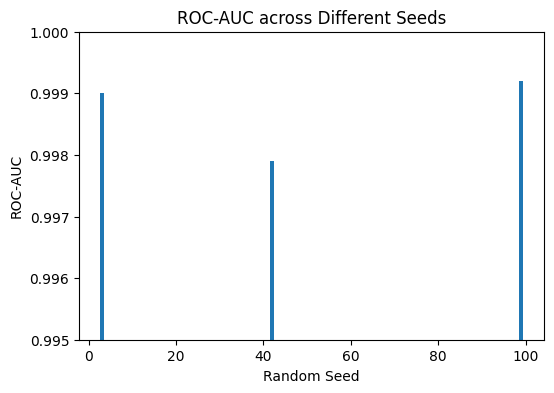

In [72]:
import matplotlib.pyplot as plt

seeds = [3, 42, 99]
aucs = [0.9990, 0.9979, 0.9992]

plt.figure(figsize=(6,4))
plt.bar(seeds, aucs)

plt.ylabel("ROC-AUC")
plt.xlabel("Random Seed")
plt.title("ROC-AUC across Different Seeds")

plt.ylim(0.995, 1.0)

plt.show()

In [73]:
# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Benign",
            "Malignant"
        ]
    )
)


Classification Report:

              precision    recall  f1-score   support

      Benign       0.97      0.98      0.98       372
   Malignant       0.99      0.99      0.99       815

    accuracy                           0.99      1187
   macro avg       0.98      0.98      0.98      1187
weighted avg       0.99      0.99      0.99      1187



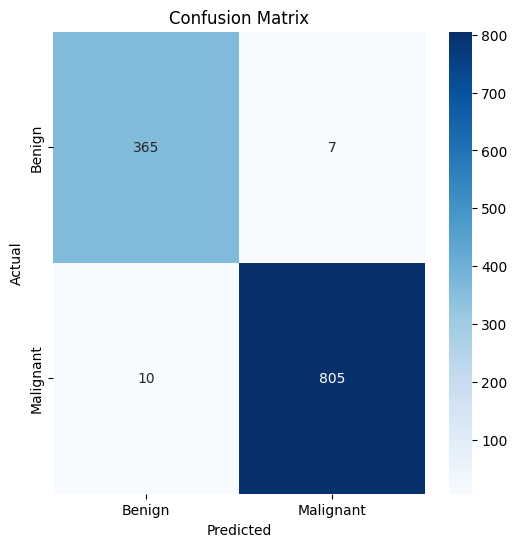

In [74]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[
        'Benign',
        'Malignant'
    ],
    yticklabels=[
        'Benign',
        'Malignant'
    ]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [75]:
# =========================================================
# SPECIFICITY
# =========================================================

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print(
    f"Specificity : {specificity*100:.2f}%"
)

Specificity : 98.12%


In [76]:

# =========================================================
# COHEN KAPPA
# =========================================================

from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
    all_labels,
    all_preds
)

print(
    f"Cohen Kappa : {kappa:.4f}"
)

Cohen Kappa : 0.9668


In [77]:
from sklearn.metrics import roc_curve, auc
import numpy as np

model.eval()

y_true = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(cfg.DEVICE)

        outputs = model(images)

        probs = torch.softmax(
            outputs,
            dim=1
        )[:,1]

        y_prob.extend(
            probs.cpu().numpy()
        )

        y_true.extend(
            labels.numpy()
        )

# SAVE FOR LATER
np.save(
    f"y_true_seed_{SEED}.npy",
    np.array(y_true)
)

np.save(
    f"y_prob_seed_{SEED}.npy",
    np.array(y_prob)
)

print(
    f"Seed {SEED} ROC data saved."
)

Seed 99 ROC data saved.


In [78]:
print(os.path.exists("y_true_seed_99.npy"))
print(os.path.exists("y_prob_seed_99.npy"))

True
True


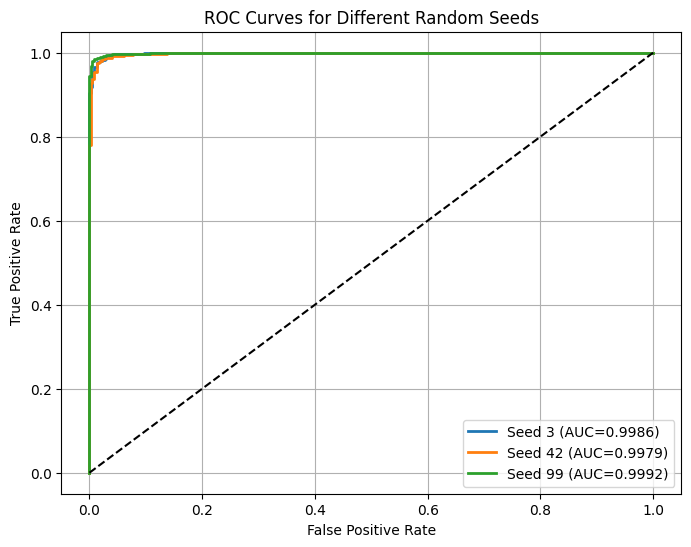

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for seed in [3,42,99]:

    y_true = np.load(f"y_true_seed_{seed}.npy")
    y_prob = np.load(f"y_prob_seed_{seed}.npy")

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Seed {seed} (AUC={roc_auc:.4f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Random Seeds")
plt.legend()
plt.grid(True)

plt.savefig(
    "/kaggle/working/Combined_ROC_Seeds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

features = []
labels_list = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(cfg.DEVICE)

        # MobileNet Features
        feat1 = model.model1(images)

        # EfficientNet Features
        feat2 = model.model2(images)

        # Fusion
        fused = torch.cat(
            [feat1, feat2],
            dim=1
        )

        features.append(
            fused.cpu().numpy()
        )

        labels_list.append(
            labels.numpy()
        )

# Merge all batches
features = np.concatenate(features, axis=0)

labels_list = np.concatenate(
    labels_list,
    axis=0
)

print("Feature Shape:", features.shape)

Feature Shape: (1187, 1856)


In [85]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

features_2d = tsne.fit_transform(
    features
)

print(features_2d.shape)

(1187, 2)


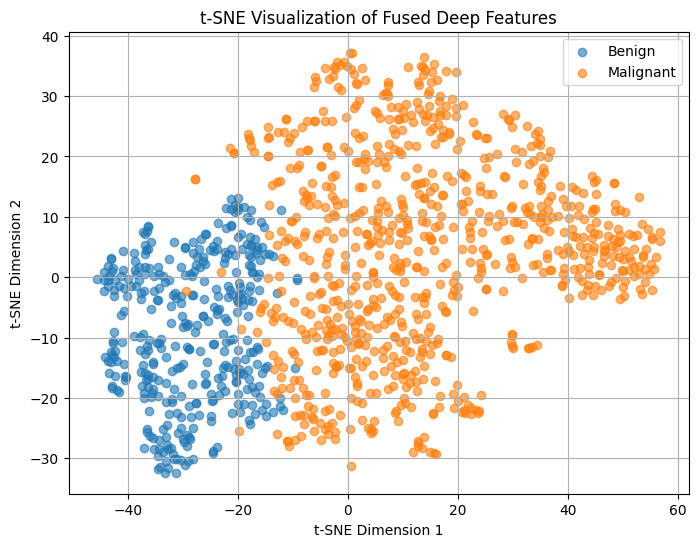

In [86]:
plt.figure(figsize=(8,6))

plt.scatter(
    features_2d[labels_list==0,0],
    features_2d[labels_list==0,1],
    alpha=0.6,
    label="Benign"
)

plt.scatter(
    features_2d[labels_list==1,0],
    features_2d[labels_list==1,1],
    alpha=0.6,
    label="Malignant"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.title(
    "t-SNE Visualization of Fused Deep Features"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "TSNE_Hybrid_Features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()